In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
from sklearn.linear_model import LinearRegression

In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT/ "datasets"
IPEDS_DIR = DATA_DIR / "ipeds"
PROCESSED_DIR = IPEDS_DIR / "processed"

FRED_PATH = DATA_DIR / "fred"

PREDICTION_DIR = DATA_DIR / "predictions"

In [7]:
application_fee_data = pd.read_csv(PROCESSED_DIR / "merged_application_fees.csv")
extra = application_fee_data.T.reset_index()
extra

,index,0,1,2,3,4,5,6,7,8,...,22844,22845,22846,22847,22848,22849,22850,22851,22852,22853
0,UNITID,14,1025,1408,1593,1595,1627,1733,1755,1942,...,500388,500397,500403,500412,500421,500430,500449,500467,500537,500555
1,1986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df = application_fee_data.T.reset_index()
df.columns = df.iloc[0]
df = df.rename(columns={"UNITID": "YEAR"})
df = df.drop(0)
# df = df.rename(columns={df.columns[0]: "YEAR"})
# df = df.set_index(df.iloc[:, 0])
# df = df.drop(df.columns[0], axis=1)
df = df.replace(".", 0)
df = df.astype(float)
df.columns = df.columns.astype(str)
df = df.reset_index(drop=True)
df

/var/folders/bj/_chbshms4bd63hgqm8v__pk40000gn/T/ipykernel_5282/1218102591.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(".", 0)


,YEAR,14,1025,1408,1593,1595,1627,1733,1755,1942,...,500388,500397,500403,500412,500421,500430,500449,500467,500537,500555
0,1986.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1987.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1988.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1989.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1990.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1991.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1992.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1993.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1994.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1995.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='YEAR'>

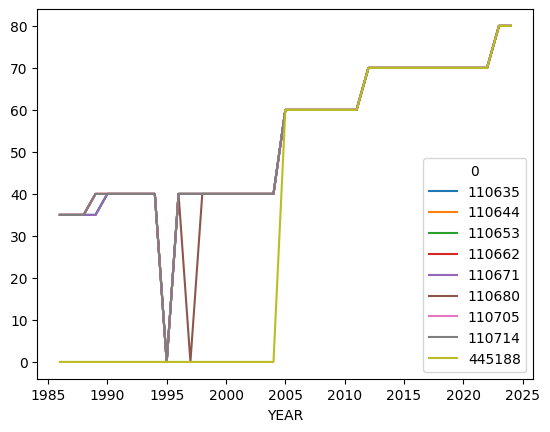

In [23]:
unitid_to_school = {
    "110635": "Berkeley",
    "110644": "Davis",
    "110653": "Irvine",
    "110662": "Los Angeles",
    "110671": "Riverside",
    "110680": "San Diego",
    "110705": "Santa Barbara",
    "110714": "Santa Cruz",
    "445188": "Merced"
}
unitids = [
    "110635",
    "110644",
    "110653",
    "110662",
    "110671",
    "110680",
    "110705",
    "110714",
    "445188"
]

# all graphs are the exact same
df.plot(x="YEAR", y=unitids)

In [13]:
inflation = pd.read_csv(FRED_PATH / "CPIAUCSL.csv")

# getting most recent year of application fee data; inflation data should never bottleneck
inflation.iloc[:, 0] = inflation.iloc[:,0].map(lambda date : re.search(r"\d{4}", date).group())
inflation = inflation.astype(float)
inflation = inflation.rename(columns={"observation_date" : "YEAR"})

# 2024 dollars baseline
base_year = 2024
baseyear_cpi = inflation[inflation["YEAR"] == base_year]["CPIAUCSL"].values
print(baseyear_cpi)

inflation_adjusted = pd.merge(df, inflation, on="YEAR", how="inner")
inflation_adjusted.iloc[:, 1:-1] = inflation_adjusted.iloc[:, 1:-1].mul(baseyear_cpi / inflation_adjusted.iloc[: , -1], axis = 0)
inflation_adjusted = inflation_adjusted.iloc[:, :-1]
inflation_adjusted

[313.698]


,YEAR,14,1025,1408,1593,1595,1627,1733,1755,1942,...,500388,500397,500403,500412,500421,500430,500449,500467,500537,500555
0,1986.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1987.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1988.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1989.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1990.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1991.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1992.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1993.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1994.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1995.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='YEAR'>

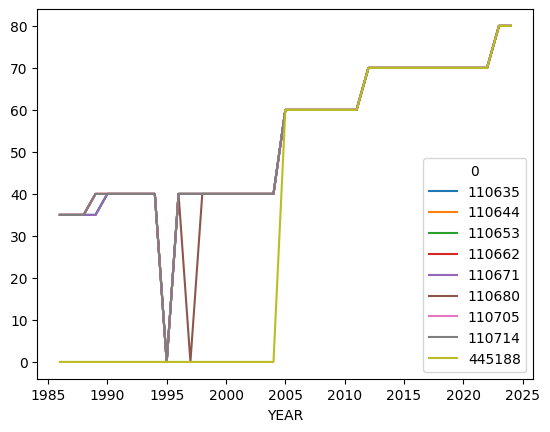

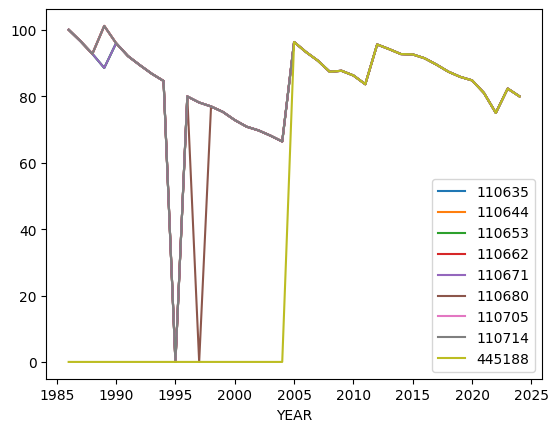

In [14]:
df.plot(x="YEAR", y=unitids)
inflation_adjusted.plot(x="YEAR", y=unitids)

In [15]:
# outputs boolean series of what to drop
def trim_outliers(series : pd.Series) -> pd.Series:
    # IQR test for outliers
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    IQR_outlier = (series >= Q1 - 1.5 * IQR) & (series <= Q3 + 1.5 * IQR)

    # dropping 0s
    zeroes = series != float(0)
    
    keep_list = IQR_outlier & zeroes

    return keep_list

Coefficients: [-0.09889744]
Intercept: 283.69908516157477


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


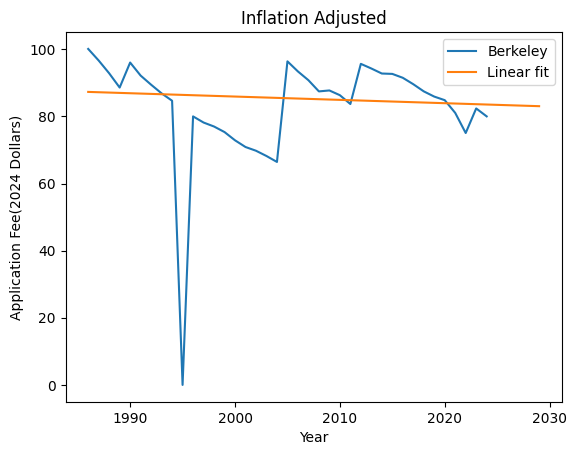

Coefficients: [-0.14144346]
Intercept: 369.3480841841996


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


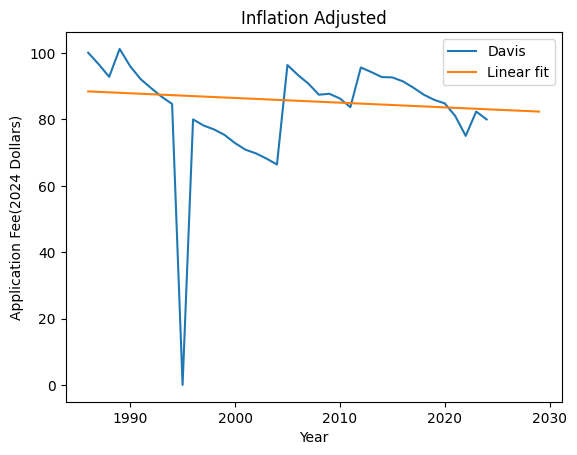

Coefficients: [-0.09889744]
Intercept: 283.69908516157477


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


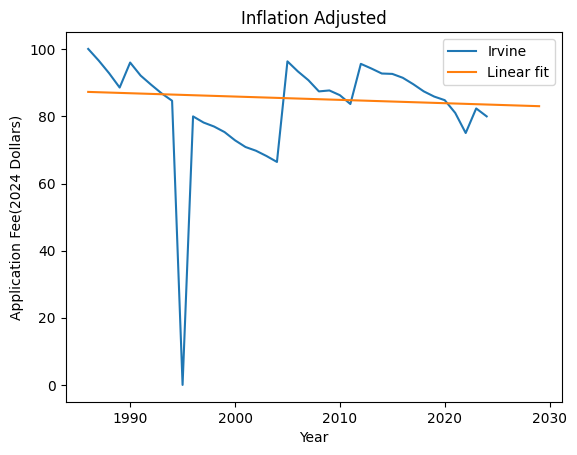

Coefficients: [-0.14144346]
Intercept: 369.3480841841996


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


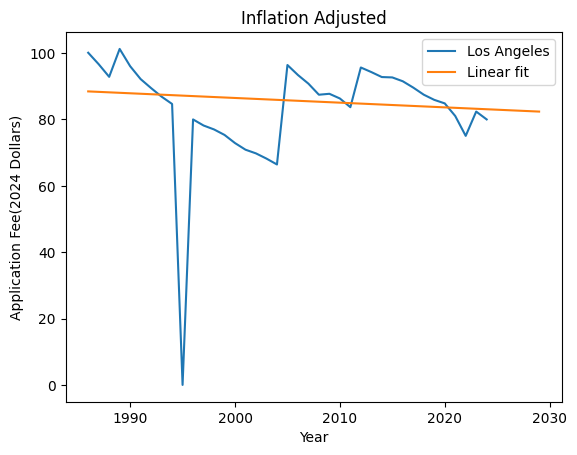

Coefficients: [-0.09889744]
Intercept: 283.69908516157477


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


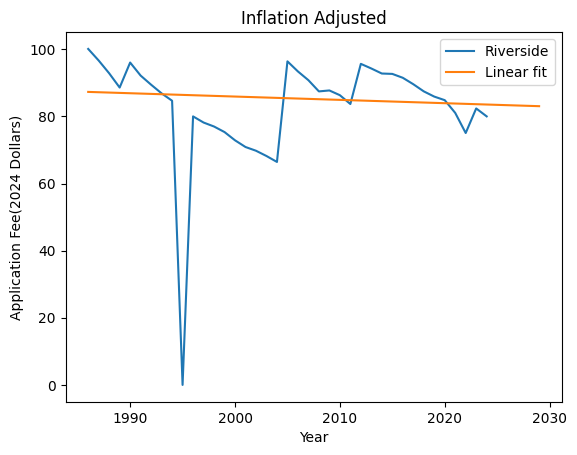

Coefficients: [-0.15696202]
Intercept: 400.70594364149935


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


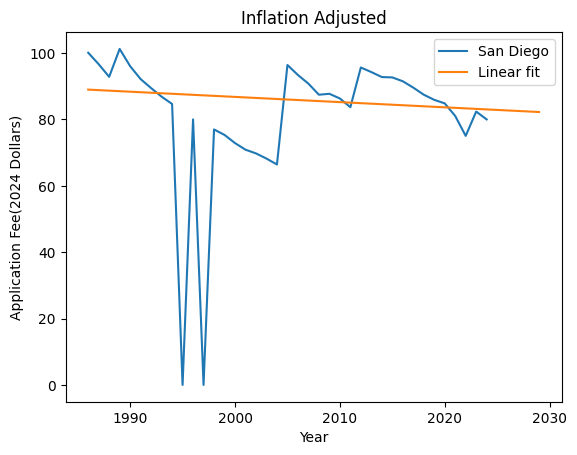

Coefficients: [-0.14144346]
Intercept: 369.3480841841996


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


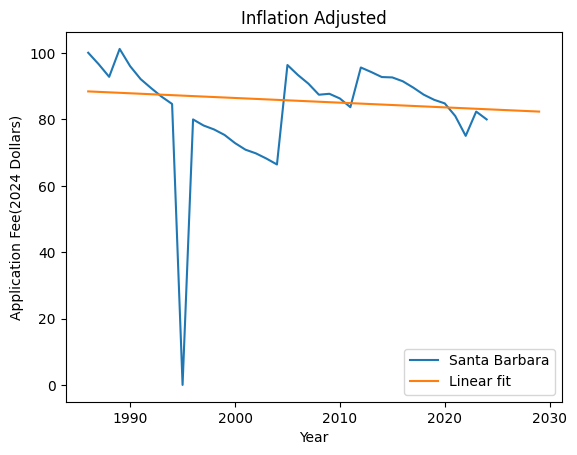

Coefficients: [-0.14144346]
Intercept: 369.3480841841996


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


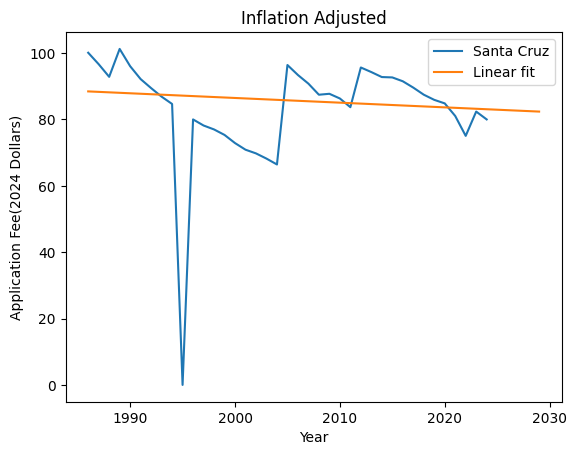

Coefficients: [-0.65106944]
Intercept: 1399.515263460267


/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


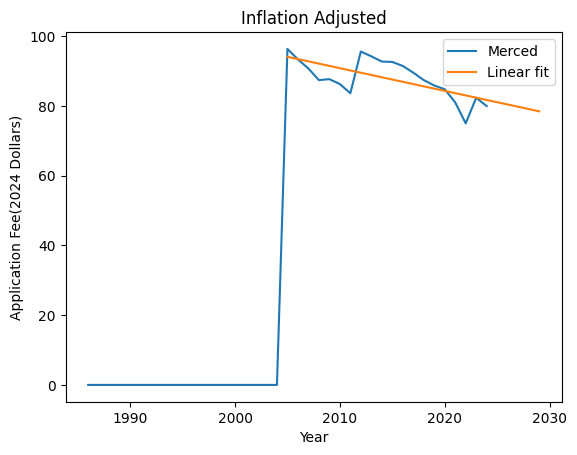

In [35]:
unitids = [
    "110635",
    "110644",
    "110653",
    "110662",
    "110671",
    "110680",
    "110705",
    "110714",
    "445188"
]

horizon = 5

all_predictions = [] 

for schoolid in unitids:
    model = LinearRegression(fit_intercept=True)

    # boolean series for outliers
    keep = trim_outliers(df[schoolid]) & (df[schoolid] != 0)

    # x
    years_series = df.loc[keep, "YEAR"]

    training_years = pd.DataFrame(years_series)

    final_year = years_series.iloc[-1]
    future_years = pd.Series([year for year in range(int(final_year + 1), int(final_year + horizon + 1))])
    all_years = pd.DataFrame(pd.concat([years_series, future_years]))

    #y
    # app_cost = df.loc[keep, schoolid]
    inflat_app_cost = inflation_adjusted.loc[keep, schoolid]


    # # model and plot for non inflation-adjusted data
    # model.fit(training_years, app_cost)
    # print("Coefficients:", model.coef_)
    # print("Intercept:", model.intercept_)
    # y_pred = model.predict(all_years)
    
    # df.plot(x="YEAR", y=unitids)
    # plt.plot(all_years, y_pred, label="Linear fit")
    # plt.xlabel("x_col")
    # plt.ylabel("y_col")
    # plt.legend()
    # plt.show()

    # inflation-adjusted
    model.fit(training_years, inflat_app_cost)
    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    y_pred = model.predict(all_years)

    all_predictions.append(pd.DataFrame({
        "YEAR" : all_years.iloc[:, 0], 
        unitid_to_school[schoolid] : y_pred
    }))
    
    inflation_adjusted.plot(x="YEAR", y=schoolid)
    plt.plot(all_years.iloc[:,0], y_pred, label="Linear fit")
    plt.xlabel("Year")
    plt.ylabel("Application Fee(2024 Dollars)")
    plt.title('Inflation Adjusted')
    plt.legend([unitid_to_school[schoolid], "Linear fit"])
    plt.show()

# note: while the graph shows the 0 point (1995), the linear regression ignores it

In [17]:
for prediction in all_predictions:
    prediction.set_index("YEAR", inplace=True)
output = pd.concat(all_predictions, axis = 1, join="outer")

output

,Berkeley,Davis,Irvine,Los Angeles,Riverside,San Diego,Santa Barbara,Santa Cruz,Merced
YEAR,,,,,,,,,
1986.0,87.288765,88.441363,87.288765,88.441363,87.288765,88.979373,88.441363,88.441363,NaN
1987.0,87.189868,88.299920,87.189868,88.299920,87.189868,88.822411,88.299920,88.299920,NaN
1988.0,87.090971,88.158476,87.090971,88.158476,87.090971,88.665449,88.158476,88.158476,NaN
1989.0,86.992073,88.017033,86.992073,88.017033,86.992073,88.508487,88.017033,88.017033,NaN
1990.0,86.893176,87.875590,86.893176,87.875590,86.893176,88.351525,87.875590,87.875590,NaN
1991.0,86.794278,87.734146,86.794278,87.734146,86.794278,88.194563,87.734146,87.734146,NaN
1992.0,86.695381,87.592703,86.695381,87.592703,86.695381,88.037601,87.592703,87.592703,NaN
1993.0,86.596483,87.451259,86.596483,87.451259,86.596483,87.880639,87.451259,87.451259,NaN
1994.0,86.497586,87.309816,86.497586,87.309816,86.497586,87.723677,87.309816,87.309816,NaN


In [20]:
output = output.reset_index()
output.to_csv(PREDICTION_DIR / "uc_application_fee_predictions.csv", index=False)

In [21]:
uc_historicals = inflation_adjusted.loc[:, unitids]
uc_historicals.columns = [unitid_to_school[schoolid] for schoolid in uc_historicals.columns] 
uc_historicals = pd.concat([inflation_adjusted["YEAR"], uc_historicals], axis = 1)

uc_historicals.to_csv(PREDICTION_DIR / "uc_application_fee_historicals_baseyear2024.csv", index=False)